In [1]:
import pandas as pd

# 读取data1目录下的all_A_papers.xlsx文件,获得索引和award列
df = pd.read_excel('all_A_papers.xlsx', usecols=['award'])
df.head()
# 读取result/global_loss/global/{index}_similarity_distance.csv   里面结构是node1  node2  similarity  distance
# 获得award=1的index列表和award=0的index列表
award_1_index = df[df['award'] == 1].index
award_0_index = df[df['award'] == 0].index

In [2]:
# 遍历award_1_index列表，读取对应的csv文件，获得similarity列和distance列
award_1_similarity = []
award_1_distance = []
for index in award_1_index:
    file_path = f'roberta/global_loss/{index}_similarity_distance.csv'
    df = pd.read_csv(file_path)
    award_1_similarity.append(df['similarity'])
    award_1_distance.append(df['distance'])

# 遍历award_0_index列表，读取对应的csv文件，获得similarity列和distance列
award_0_similarity = []
award_0_distance = []
for index in award_0_index:
    file_path = f'roberta/global_loss/{index}_similarity_distance.csv'
    df = pd.read_csv(file_path)
    award_0_similarity.append(df['similarity'])
    award_0_distance.append(df['distance'])


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 读取data1目录下的all_A_papers.xlsx文件,获得索引和award列
# df = pd.read_excel('all_A_papers.xlsx')
df = pd.read_excel('all_A_papers_innovation.xlsx')
# 如果 DataFrame 中不存在 'innovation' 列，先创建它并初始化为 NaN
if 'innovation' not in df.columns:
    df['innovation'] = np.nan
if 'influentialCitationCount' not in df.columns:
    df['influentialCitationCount'] = np.nan
if 'citationCount' not in df.columns:
    df['citationCount'] = np.nan
df.head()
# 遍历df
for index, row in df.iterrows():
    # 首先判断award是否为nan或空
    if pd.isnull(row['award']):
        continue
    award = row['award']
    file_path = f'roberta/global_loss/{index}_similarity_distance.csv'
    linshi_df = pd.read_csv(file_path)

    a = 1
    b = 1
    # linshi_df['innovation'] = a*(1-linshi_df['similarity'])/2 + b*linshi_df['distance']
    linshi_df['innovation'] = (1-linshi_df['similarity'])/2
    innovation = linshi_df['innovation'].sum()
    df.loc[index,'innovation'] = innovation

    #file_path2 = f'data/{index}_paper.csv'
    #paper_df = pd.read_csv(file_path2)
    #df.loc[index, 'influentialCitationCount'] = paper_df.loc[0,'influentialCitationCount']
    #df.loc[index, 'citationCount'] = paper_df.loc[0,'citationCount']
    #if paper_df.loc[0,'influentialCitationCount'] >= 10:
    #    df.loc[index, 'award'] = 1

#df = df.dropna(subset=['award'])
output_file = 'all_A_papers_innovation.xlsx'
df.to_excel(output_file, index=False)

# 读取result/global_loss/global/{index}_similarity_distance.csv   里面结构是node1  node2  similarity  distance

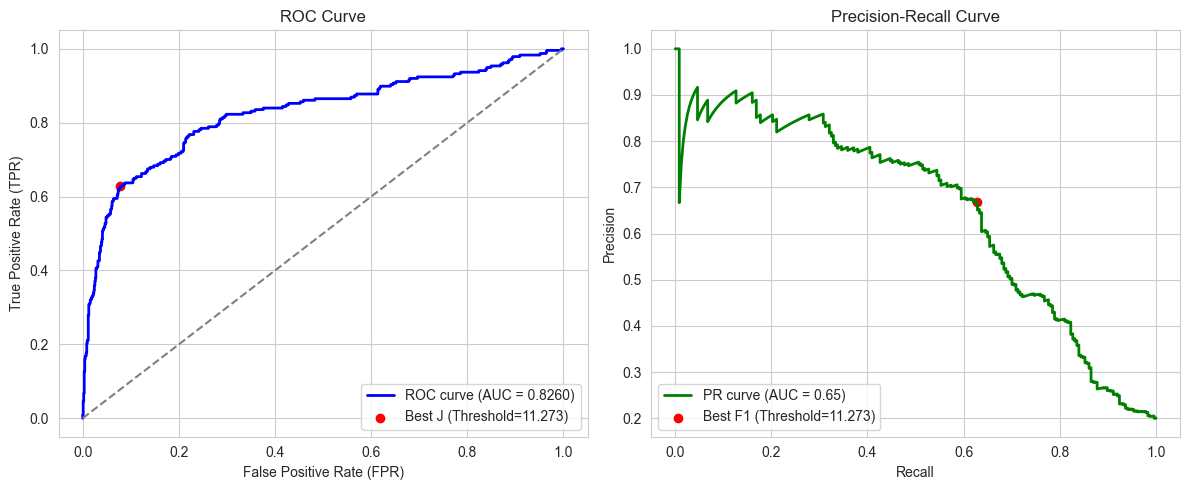

最佳 Youden's J 阈值: 11.2727
最佳 F1-score 阈值: 11.2727


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
# 读取数据
# df = pd.read_excel('../result/global_loss/all_A_papers_innovation - 副本.xlsx')
df = pd.read_excel('all_A_papers_innovation.xlsx')
df = df.dropna(subset=['award'])  # 删除缺失值

# 真实标签和预测得分
y_true = df['award']
y_scores = df['innovation']

# 计算 ROC 曲线
fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 计算 PR 曲线
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)
pr_auc = auc(recall, precision)

# 计算最佳阈值：
# 1. 使用 Youden's J 统计量
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

# 2. 计算 F1-score 选择最佳阈值
f1_scores = 2 * (precision * recall) / (precision + recall)
best_f1_idx = np.nanargmax(f1_scores)  # 避免 NaN 影响
best_f1_threshold = pr_thresholds[best_f1_idx]

# 画图：ROC 曲线
plt.figure(figsize=(12, 5))

# --- 左侧：ROC 曲线 ---
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 参考线
plt.scatter(fpr[best_j_idx], tpr[best_j_idx], color='red', label=f'Best J (Threshold={best_j_threshold:.3f})')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)

# --- 右侧：PR 曲线 ---
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
plt.scatter(recall[best_f1_idx], precision[best_f1_idx], color='red', label=f'Best F1 (Threshold={best_f1_threshold:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()

# 打印最佳阈值
print(f"最佳 Youden's J 阈值: {best_j_threshold:.4f}")
print(f"最佳 F1-score 阈值: {best_f1_threshold:.4f}")


In [2]:
import pandas as pd
# 示例数据
df = pd.read_excel('all_A_papers_innovation.xlsx')
df = df.dropna(subset=['award'])  # 删除缺失值
# 真实标签
y_true = df['award']  # 假设 'award' 列是实际标签（0: 不患病, 1: 患病）
# 模型预测得分
y_scores = df['innovation']  # 假设 'innovation' 列是模型给出的患病可能性
# 设置阈值
threshold = 11.27
# 使用阈值进行分类
y_pred = (y_scores > threshold).astype(int)
# 计算分类性能（精确度、召回率、F1分数等）
from sklearn.metrics import classification_report
report_dict = classification_report(y_true, y_pred, output_dict=True)  # 以字典格式输出
macro_avg = report_dict["macro avg"]
print(macro_avg)

{'precision': 0.7883426717507436, 'recall': 0.7753164556962024, 'f1-score': 0.7815046665149101, 'support': 1185.0}


C:\Users\wangzeren\AppData\Local\Temp\ipykernel_23020\1517068601.py:100: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='FPR', y='TPR', hue='Model', lw=2, palette=palette,


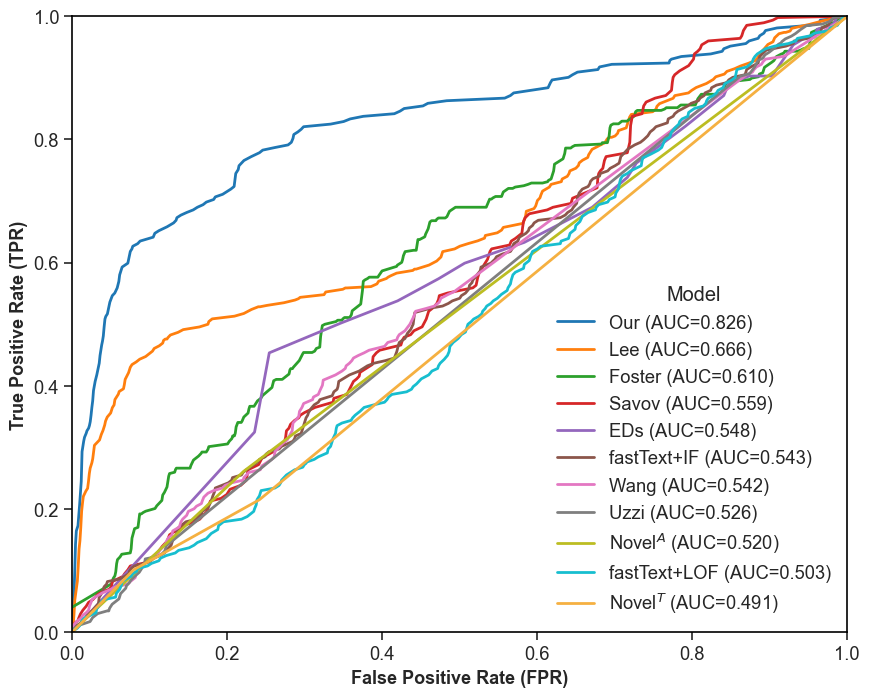

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
df = pd.read_excel('all_A_papers_innovation.xlsx')
df = df.dropna(subset=['award'])  # 删除缺失值
# 真实标签和预测得分
y_true = df['award']
y_scores1 = df['innovation']
# 计算不同模型的 FPR, TPR 和 AUC
fpr1, tpr1, _ = roc_curve(y_true, y_scores1)
roc_auc1 = auc(fpr1, tpr1)

df = pd.read_excel('other_method/savov_innovation.xlsx')
y_scores2 = df['innovation_score']  # 模型得分
fpr2, tpr2, _ = roc_curve(y_true, y_scores2)
roc_auc2 = auc(fpr2, tpr2)

df = pd.read_excel('other_method/Wang_2023_innovation.xlsx')
y_scores3 = df['innovation_score']  # 模型得分
fpr3, tpr3, _ = roc_curve(y_true, y_scores3)
roc_auc3 = auc(fpr3, tpr3)

df = pd.read_csv('other_method/shibayama.csv')
y_scores4 = df['title_8Q']  # 模型得分
y_scores5 = df['abstract_8Q']  # 模型得分
fpr4, tpr4, _ = roc_curve(y_true, y_scores4)
roc_auc4 = auc(fpr4, tpr4)
fpr5, tpr5, _ = roc_curve(y_true, y_scores5)
roc_auc5 = auc(fpr5, tpr5)

df = pd.read_csv('other_method/uzzi_innovation.csv')
y_true = df['award']
y_scores6 = df['novelty']  # 模型得分
fpr6, tpr6, _ = roc_curve(y_true, y_scores6)
roc_auc6 = auc(fpr6, tpr6)

df = pd.read_csv('other_method/lee_innovation.csv')
y_scores7 = df['novelty']  # 模型得分
y_true = df['award']
fpr7, tpr7, _ = roc_curve(y_true, y_scores7)
roc_auc7 = auc(fpr7, tpr7)

df = pd.read_csv('other_method/foster_innovation.csv')
y_scores8 = df['novelty']  # 模型得分
y_true = df['award']
fpr8, tpr8, _ = roc_curve(y_true, y_scores8)
roc_auc8 = auc(fpr8, tpr8)

df = pd.read_excel('D:/document/project/wang2017_novelty.xlsx')
y_scores9 = df['novelty_score']  # 模型得分
y_true = df['award']
fpr9, tpr9, _ = roc_curve(y_true, y_scores9)
roc_auc9 = auc(fpr9, tpr9)

df = pd.read_excel('D:/document/project/fast2023.xlsx')
y_scores10 = df['fastText+LOF']  # 模型得分
y_true = df['award']
fpr10, tpr10, _ = roc_curve(y_true, y_scores10)
roc_auc10 = auc(fpr10, tpr10)
y_scores11 = df['fastText+IF']  # 模型得分
y_true = df['award']
fpr11, tpr11, _ = roc_curve(y_true, y_scores11)
roc_auc11 = auc(fpr11, tpr11)

# 构造 DataFrame 适配 seaborn
df1 = pd.DataFrame({'FPR': fpr1, 'TPR': tpr1, 'Model': f'Our (AUC={roc_auc1:.3f})'})
df2 = pd.DataFrame({'FPR': fpr2, 'TPR': tpr2, 'Model': f'Savov (AUC={roc_auc2:.3f})'})
df3 = pd.DataFrame({'FPR': fpr3, 'TPR': tpr3, 'Model': f'EDs (AUC={roc_auc3:.3f})'})
df4 = pd.DataFrame({'FPR': fpr4, 'TPR': tpr4, 'Model': fr'Novel$^{{T}}$ (AUC={roc_auc4:.3f})'})
df5 = pd.DataFrame({'FPR': fpr5, 'TPR': tpr5, 'Model': fr'Novel$^{{A}}$ (AUC={roc_auc5:.3f})'})
df6 = pd.DataFrame({'FPR': fpr6, 'TPR': tpr6, 'Model': f'Uzzi (AUC={roc_auc6:.3f})'})
df7 = pd.DataFrame({'FPR': fpr7, 'TPR': tpr7, 'Model': f'Lee (AUC={roc_auc7:.3f})'})
df8 = pd.DataFrame({'FPR': fpr8, 'TPR': tpr8, 'Model': f'Foster (AUC={roc_auc8:.3f})'})
df9 = pd.DataFrame({'FPR': fpr9, 'TPR': tpr9, 'Model': f'Wang (AUC={roc_auc9:.3f})'})
df10 = pd.DataFrame({'FPR': fpr10, 'TPR': tpr10, 'Model': f'fastText+LOF (AUC={roc_auc10:.3f})'})
df11 = pd.DataFrame({'FPR': fpr11, 'TPR': tpr11, 'Model': f'fastText+IF (AUC={roc_auc11:.3f})'})
#df5 = pd.DataFrame({'FPR': fpr5, 'TPR': tpr5, 'Model': f'Lee (AUC={roc_auc5:.2f})'})
#df7 = pd.DataFrame({'FPR': fpr7, 'TPR': tpr7, 'Model': f'wang (AUC={roc_auc7:.2f})'})


#df = pd.concat([df1, df2, df3,df4,df5,df6,df7,df8])
df = pd.concat([df1, df7,df8,df2, df3,df11,df9,df6,df5,df10,df4])

# 设置 Seaborn 样式
# sns.set(style="whitegrid", palette="pastel")  # 设置更适合的调色板
# 使用 `Set2` 色调，手动提取 8 种颜色
# palette = ['#0080ff','#ff8040','#f0ce0f','#e10000','#40E0D0','#8001ff','#008000','#818104']
# 优化调色板：选择更科研感 + 区分度更高的颜色
sns.set_context("notebook", font_scale=1.2)
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
           '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
           '#bcbd22', '#17becf', '#f5b041']
#coolwarm_palette  = sns.color_palette("coolwarm", 9)  #Set2还不错
#palette = [set2_palette[i] if i % 2 == 0 else coolwarm_palette[i] for i in range(8)]

# 开始绘制
plt.figure(figsize=(10, 8))
sns.lineplot(data=df, x='FPR', y='TPR', hue='Model', lw=2, palette=palette,
             ci=None)

# 画随机猜测的参考线
#plt.plot([0, 1], [0, 1], linestyle="--", color='gray')

# 设定图像范围
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

# 添加标签和标题
plt.xlabel('False Positive Rate (FPR)', fontsize=13,fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=13,fontweight='bold')
plt.title('')
plt.grid(False)
plt.tick_params(axis='both', which='both', bottom=True, top=False, left=True,right=False, direction='out', length=6, width=1.2)
#隐藏 y=0.70 的那根刻度线
ax = plt.gca()

for spine in ['bottom', 'left', 'top', 'right']:
    ax.spines[spine].set_linewidth(1.2)
    ax.spines[spine].set_color('black')


plt.legend(title='Model', loc='lower right', frameon=False)
plt.savefig('comparative.png', dpi=300, format='png')
# 显示图像
plt.show()

# 计算最佳阈值

In [6]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
df = pd.read_excel('all_A_papers_innovation.xlsx')
df = df.dropna(subset=['award'])  # 删除缺失值
# 真实标签和预测得分
y_true = df['award']
y_true1 = df['award']
y_scores1 = df['innovation']
# 计算不同模型的 FPR, TPR 和 AUC
fpr1, tpr1, thresholds1  = roc_curve(y_true, y_scores1)
roc_auc1 = auc(fpr1, tpr1)
optimal1 = np.argmax(tpr1 - fpr1)  # tpr - fpr 最大值时的索引
threshold1 = thresholds1[optimal1]

df = pd.read_excel('other_method/savov_innovation.xlsx')
y_true2 = y_true1
y_scores2 = df['innovation_score']  # 模型得分
fpr2, tpr2, thresholds2 = roc_curve(y_true, y_scores2)
roc_auc2 = auc(fpr2, tpr2)
optimal2 = np.argmax(tpr2 - fpr2)  # tpr - fpr 最大值时的索引
threshold2 = thresholds2[optimal2]


df = pd.read_excel('other_method/Wang_2023_innovation.xlsx')
y_true3 = y_true1
y_scores3 = df['innovation_score']  # 模型得分
fpr3, tpr3, thresholds3 = roc_curve(y_true, y_scores3)
roc_auc3 = auc(fpr3, tpr3)
optimal3 = np.argmax(tpr3 - fpr3)  # tpr - fpr 最大值时的索引
threshold3 = thresholds3[optimal3]

df = pd.read_csv('other_method/shibayama.csv')
y_true4 = y_true1
y_true5 = y_true1
y_scores4 = df['title_8Q']  # 模型得分
y_scores5 = df['abstract_8Q']  # 模型得分
fpr4, tpr4, thresholds4 = roc_curve(y_true, y_scores4)
roc_auc4 = auc(fpr4, tpr4)
optimal4 = np.argmax(tpr4 - fpr4)  # tpr - fpr 最大值时的索引
threshold4 = thresholds4[optimal4]

fpr5, tpr5, thresholds5 = roc_curve(y_true, y_scores5)
roc_auc5 = auc(fpr5, tpr5)
optimal5 = np.argmax(tpr5 - fpr5)  # tpr - fpr 最大值时的索引
threshold5 = thresholds5[optimal5]

df = pd.read_csv('other_method/uzzi_innovation.csv')
y_true6 = df['award']
y_scores6 = df['novelty']  # 模型得分
fpr6, tpr6, thresholds6 = roc_curve(y_true6, y_scores6)
roc_auc6 = auc(fpr6, tpr6)
optimal6 = np.argmax(tpr6 - fpr6)  # tpr - fpr 最大值时的索引
threshold6 = thresholds6[optimal6]

df = pd.read_csv('other_method/lee_innovation.csv')
y_scores7 = df['novelty']  # 模型得分
y_true7 = df['award']
fpr7, tpr7, thresholds7 = roc_curve(y_true7, y_scores7)
roc_auc7 = auc(fpr7, tpr7)
optimal7 = np.argmax(tpr7 - fpr7)  # tpr - fpr 最大值时的索引
threshold7 = thresholds7[optimal7]

df = pd.read_csv('other_method/foster_innovation.csv')
y_scores8 = df['novelty']  # 模型得分
y_true8 = df['award']
fpr8, tpr8, thresholds8 = roc_curve(y_true8, y_scores8)
roc_auc8 = auc(fpr8, tpr8)
optimal8 = np.argmax(tpr8 - fpr8)  # tpr - fpr 最大值时的索引
threshold8 = thresholds8[optimal8]

df = pd.read_excel('D:/document/project/wang2017_novelty.xlsx')
y_scores9 = df['novelty_score']  # 模型得分
y_true9 = df['award']
fpr9, tpr9, thresholds9 = roc_curve(y_true, y_scores9)
roc_auc9 = auc(fpr9, tpr9)

df = pd.read_excel('D:/document/project/fast2023.xlsx')
y_scores10 = df['fastText+LOF']  # 模型得分
y_true10 = df['award']
fpr10, tpr10, thresholds10 = roc_curve(y_true, y_scores10)
roc_auc10 = auc(fpr10, tpr10)

y_scores11 = df['fastText+IF']  # 模型得分
y_true11 = df['award']
fpr11, tpr11, thresholds11 = roc_curve(y_true, y_scores11)
roc_auc11 = auc(fpr11, tpr11)

In [7]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, auc
# 初始化最佳 F1 和阈值
best_f1 = 0
best_threshold = None
best_metrics = {}

# 遍历所有阈值，计算对应的 F1
for threshold in thresholds10:
    y_pred = (y_scores10 >= threshold).astype(int)
    f1 = f1_score(y_true10, y_pred, average='macro')  # 你也可以用 binary，看任务类型
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_metrics = {
            'precision': precision_score(y_true10, y_pred, average='macro'),
            'recall': recall_score(y_true10, y_pred, average='macro'),
            'f1': f1,
            'accuracy': accuracy_score(y_true10, y_pred)
        }
print(f"Best F1 threshold: {best_threshold:.4f}")
print(f"Best metrics: {best_metrics}")

D:\Anaconda3\envs\breakthrough\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best F1 threshold: 1.4363
Best metrics: {'precision': 0.5208994708994709, 'recall': 0.510548523206751, 'f1': 0.5011073047510295, 'accuracy': 0.7535864978902953}
